In [1]:
import numpy as np
import sys
from pathlib import Path

sys.path.append('../code/')

from mlalgos import HyperOpt
from mllib import Utilities,MLUtilities

from time import time
import copy,pickle

import matplotlib.pyplot as plt
from matplotlib import gridspec
import matplotlib as mpl
import matplotlib.colors as pltcol
import gc

import tensorflow as tf

ut = Utilities()
ml = MLUtilities()

I0000 00:00:1784341860.927246  893339 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784341860.928293  893339 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1784341860.995086  893339 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1784341862.213234  893339 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

In [2]:
mpl.rcParams['xtick.direction'] = 'in'
mpl.rcParams['ytick.direction'] = 'in'
mpl.rcParams['xtick.top'] = True
mpl.rcParams['ytick.right'] = True
mpl.rcParams['xtick.labelsize'] = 14
mpl.rcParams['ytick.labelsize'] = 14
mpl.rcParams['axes.labelsize'] = 16
mpl.rcParams['legend.fontsize'] = 14 # 14
mpl.rcParams['legend.labelspacing'] = 0.25
FS = 18
FS2 = 15
FS3 = 14
FSS = 12
FSL = 22

mpl.rcParams['xtick.major.size'] = 6
mpl.rcParams['xtick.minor.size'] = 3
mpl.rcParams['ytick.major.size'] = 6
mpl.rcParams['ytick.minor.size'] = 3

#mpl.rcParams.keys()

# Example usage of curriculum learning  
### using shallow networks with `HyperOpt` for optimization

In [3]:
Baseline = False # set to True to establish zero noise baseline
Out_Stem = 'curriculum/'

Plot_Stem = Out_Stem + 'plots'
Path(Plot_Stem).mkdir(parents=True,exist_ok=True)

N_Lessons = 72      # number of actual noise lessons in training data
N_Lessons_Train = 9 # number of lessons in training curriculum
N_Levels  = 2       # number of difficulty levels in test data

Noise_Schedule = np.logspace(0.0,2.0,N_Lessons)
if Baseline:
    Noise_Schedule *= 0.0

Nproc = 1 # large mem reqs for MNIST mean 1 is best

Save_Fig = True
print('noise schedule:\n',Noise_Schedule)

noise schedule:
 [  1.           1.06701129   1.13851309   1.21480632   1.29621206
   1.3830729    1.47575439   1.5746466    1.68016569   1.79275576
   1.91289063   2.0410759    2.17785103   2.32379163   2.4795119
   2.64566719   2.82295676   3.01212673   3.21397322   3.4293457
   3.65915058   3.90435497   4.16599083   4.44515925   4.74303509
   5.06087199   5.40000754   5.761869     6.14797927   6.55996328
   6.99955487   7.46860406   7.96908485   8.50310349   9.07290741
   9.68089463  10.32962385  11.02182525  11.76041196  12.54849232
  13.38938296  14.28662277  15.24398777  16.26550703  17.35547961
  18.51849266  19.75944072  21.0835463   22.4963819   24.00389344
  25.61242527  27.32874689  29.16008143  31.11413606  33.1991344
  35.42385118  37.79764909  40.33051826  43.03311825  45.91682295
  48.99376842  52.27690397  55.78004666  59.51793946  63.50631327
  67.76195315  72.30276894  77.14787065  82.31764887  87.83386058
  93.71972076 100.        ]


In [4]:
Depth_Str = 'shallow'
Plot_Str = '' + Depth_Str

Family = 'seq'

## Classification example: MNIST

### Data setup with levels of increasing difficulty (noise)

In [5]:
Vortex = True     # 'vortex unroll' to partially preserve spatial coherence in flattened array
Downsample = 0.1  # 1.0 is doable on desktop: reaches ~59.6GB RAM using N = 3 x 48 jobs, scales ~ 1/N
K = 10

In [6]:
start_time = time()
(X_train_tf, Y_train_tf), (X_test_tf, Y_test_tf) = tf.keras.datasets.mnist.load_data()

print(X_train_tf.shape,Y_train_tf.shape)
print(X_test_tf.shape,Y_test_tf.shape)

if Vortex:
    print('... vortex unroll')
    X_train = ml.vortex_package(X_train_tf.T).astype(float) # (784,nsamp)
    X_test = ml.vortex_package(X_test_tf.T).astype(float) # (784,nsamp)
else:
    print('... standard flatten')
    X_train = np.zeros((X_train_tf.shape[0],X_train_tf.shape[1]**2))
    for i in range(X_train_tf.shape[0]):
        X_train[i] = X_train_tf[i].flatten()
    X_train = X_train.T
    
    X_test = np.zeros((X_test_tf.shape[0],X_test_tf.shape[1]**2))
    for i in range(X_test_tf.shape[0]):
        X_test[i] = X_test_tf[i].flatten()
    X_test = X_test.T

# don't standardize here, use 'standardize_X' instead
# X_train /= 255.0
# X_test /= 255.0

# Y has category values, not one-hot encoding
Y_train = ml.rv(Y_train_tf)
Y_test = ml.rv(Y_test_tf)

del X_train_tf,Y_train_tf
del X_test_tf,Y_test_tf
gc.collect()

eps = 1 if Y_train.min() < 1 else 0 # ml.one_hot needs values in 1..K
if K > 2:
    Y_train = ml.one_hot(Y_train+eps,K) # (K,nsamp), domain {0,1}
    Y_test = ml.one_hot(Y_test+eps,K) # (K,nsamp), domain {0,1}

print(X_train.shape,Y_train.shape)
print(X_test.shape,Y_test.shape)

rng = np.random.RandomState(1991)

if Downsample is None:
    print('... no downsampling')
    n_train = X_train.shape[1]
    n_test = X_test.shape[1]
else:
    print('... downsampling by factor {0:.3f}'.format(Downsample))
    n_train = int(Downsample*X_train.shape[1])
    n_test = int(Downsample*X_test.shape[1])  

    ind_train = rng.choice(X_train.shape[1],size=n_train,replace=False)
    ind_test = rng.choice(X_test.shape[1],size=n_test,replace=False)

    X_train = X_train[:,ind_train]
    Y_train = Y_train[:,ind_train]
    X_test = X_test[:,ind_test]
    Y_test = Y_test[:,ind_test]
    print('... retained {0:d} training and {1:d} testing samples'.format(n_train,n_test))

    del ind_train,ind_test
    gc.collect()

print('... shuffling')
ind_shuff_train = rng.choice(n_train,size=n_train,replace=False)
X_train = X_train[:,ind_shuff_train]
Y_train = Y_train[:,ind_shuff_train]

ind_shuff_test = rng.choice(n_test,size=n_test,replace=False)
X_test = X_test[:,ind_shuff_test]
Y_test = Y_test[:,ind_shuff_test]

del ind_shuff_train,ind_shuff_test
gc.collect()

for k in range(K):
    print(k,np.where(Y_train[k]==1)[0].size,np.where(Y_test[k]==1)[0].size)    


Seeds = 1983 + 2*np.arange(np.max([N_Lessons,N_Levels])) # seeds for training samples
dSeed = 5 # offset to add for test samples

print('... adding Gaussian noise')
n_train_per_lesson = n_train // N_Lessons
i_train_prev = 0
for n in range(N_Lessons):
    rng = np.random.RandomState(Seeds[n])
    n_train_this = 1*n_train_per_lesson
    i_train_this = n_train_per_lesson*(n+1)
    if n == (N_Lessons-1):
        n_train_this += (n_train % N_Lessons)
        i_train_this = n_train # last step should reach the end
    noise = Noise_Schedule[n]*rng.randn(X_train.shape[0],n_train_this)
    X_train[:,i_train_prev:i_train_this] += noise
    i_train_prev = 1*i_train_this

i_test_prev = 0
n_test_per_lesson = n_test // N_Lessons
for n in range(N_Lessons):
    rng = np.random.RandomState(Seeds[n]+dSeed)
    n_test_this = 1*n_test_per_lesson
    i_test_this = n_test_per_lesson*(n+1)
    if n == (N_Lessons-1):
        n_test_this += (n_test % N_Lessons)
        i_test_this = n_test # last step should reach the end
    noise = Noise_Schedule[n]*rng.randn(X_test.shape[0],n_test_this)
    X_test[:,i_test_prev:i_test_this] += noise
    i_test_prev = 1*i_test_this

print('... done')
ut.time_this(start_time)

(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)
... vortex unroll
(784, 60000) (10, 60000)
(784, 10000) (10, 10000)
... downsampling by factor 0.100
... retained 6000 training and 1000 testing samples
... shuffling
0 599 93
1 655 122
2 582 103
3 619 95
4 588 103
5 572 89
6 588 89
7 628 106
8 583 90
9 586 110
... adding Gaussian noise
... done
0 min 3.24 seconds



### Network setup and training

In [7]:
# dictionary containing all setup parameters and data
setup_dict = {} 

# -- data set: features and labels
setup_dict['X'] = X_train
setup_dict['Y'] = Y_train

# -- network family
setup_dict['family'] = Family

# -- curriculum
setup_dict['curriculum'] = None # will be changed below

# -- training sample 
setup_dict['train_frac'] = 0.8
setup_dict['val_frac'] = 0.2
setup_dict['loss_type'] = 'nllm'
setup_dict['neg_labels'] = False 

# -- training setup
setup_dict['standardize_X'] = True
setup_dict['max_epoch'] = 54
setup_dict['check_after'] = 54 
setup_dict['seed'] = None
setup_dict['file_stem'] = 'net' # will be changed later

#-----------------------
# total number of networks trained will be n_iter * max_config
N_Iter = 2 
Max_Config = 60
setup_dict['n_iter'] = N_Iter
setup_dict['max_config'] = Max_Config
#-----------------------

setup_dict['ensemble'] = True 
setup_dict['ensemble_size'] = 5

setup_dict['parallel'] = True
setup_dict['nproc'] = np.min([Nproc,N_Iter*Max_Config])
setup_dict['fixed_width'] = False
setup_dict['fixed_htype'] = False

# -- sampled parameters
setup_dict['layers'] = {'min':3,'max':4}
setup_dict['widths'] = {'min':150,'max':300}
setup_dict['lglrates'] = {'min':-3.5,'max':-2.0}
setup_dict['wt_decays'] = {'min':0.0,'max':0.1}
setup_dict['thresholds'] = {'min':0.4,'max':0.6}
setup_dict['htypes'] = ['tanh','splus']
# setup_dict['lrelu_slopes'] = {'min':-1e-2,'max':1e-2}
setup_dict['reg_funs'] = ['drop','none'] 
setup_dict['p_drops'] = {'min':0.0,'max':0.5}
setup_dict['slowdowns'] = {'min':1.0,'max':1.0} # will be changed for curriculum learning

# -- I/O
setup_dict['verbose'] = True
setup_dict['logfile'] = None

# -- storage for ensemble-averaged count of weights in NEO
Avg_Wts = {}

Out_Dir = Out_Stem + ('baseline/' if Baseline else 'noisy/')
print('output dir:',Out_Dir)

output dir: curriculum/noisy/


#### Curriculum learning

File_Stem: curriculum/noisy/curriculum
--------------
Hyperparameter + architecture optimization
--------------
... neural network family: Sequential
... ... curriculum network will be trained
... found data set of dimension 784 with targets of dimension 10
... found 6000 samples
... fraction 0.800 (4800 samples) will be used for training
... will search over 2 iterations of 60 configurations
... will store best 5 networks in ensemble
... will use misclassification fraction for hyperparameter comparison
... weight decays will use norm 2
... setup complete
NetworkEnsembleObject initialized
... ... initializing dict self.ensemble
... ... updating ensemble
... ... checking ensemble consistency
... ... defining ensemble weights
... ... setting ensemble threshold
... ensemble loaded and checked
0 min 0.36 seconds

Best test stats:
... curriculum/noisy/curriculum/ensemble/net_r0: 8.750e-02
... ... L: 4
... ... wt_decay: 0.06333333333333334
... ... n_layer: [270, np.int64(181), np.int64(225),

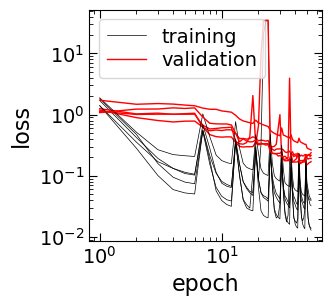

In [8]:
Optimize = False

File_Stem = Out_Dir + 'curriculum'
print('File_Stem:',File_Stem)

Curriculum = (n_train // N_Lessons_Train)*np.arange(1,N_Lessons_Train+1)

setup_dict_curr = copy.deepcopy(setup_dict)
setup_dict_curr['file_stem'] = File_Stem
setup_dict_curr['curriculum'] = Curriculum
setup_dict_curr['slowdowns'] = {'min':1.0,'max':1.5} 

start_time = time()
hopt_curr = HyperOpt(setup_dict=setup_dict_curr)

if Optimize:
    neo_curr = hopt_curr.optimize()
else:
    neo_curr = hopt_curr.load()

ut.time_this(start_time)

Avg_Wts['curr'] = neo_curr.display_summary(show_keys=['L','wt_decay','n_layer','atypes','reg_fun','threshold'],
                                           train_keys=['lrate','slowdown'],
                                           return_avg_wts=True)

#### Standard learning

File_Stem: curriculum/noisy/standard
--------------
Hyperparameter + architecture optimization
--------------
... neural network family: Sequential
... ... standard training will be implemented
... found data set of dimension 784 with targets of dimension 10
... found 6000 samples
... fraction 0.800 (4800 samples) will be used for training
... will search over 2 iterations of 60 configurations
... will store best 5 networks in ensemble
... will use misclassification fraction for hyperparameter comparison
... weight decays will use norm 2
... setup complete
NetworkEnsembleObject initialized
... ... initializing dict self.ensemble
... ... updating ensemble
... ... checking ensemble consistency
... ... defining ensemble weights
... ... setting ensemble threshold
... ensemble loaded and checked
0 min 0.18 seconds

Best test stats:
... curriculum/noisy/standard/ensemble/net_r0: 9.667e-02
... ... L: 3
... ... wt_decay: 0.09833333333333333
... ... n_layer: [220, np.int64(266), 10]
... ... aty

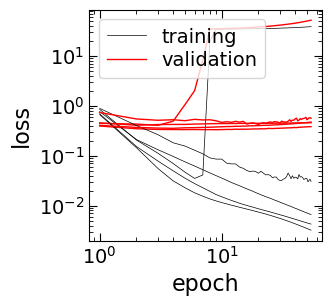

In [9]:
Optimize = False

File_Stem = Out_Dir + 'standard'
print('File_Stem:',File_Stem)

setup_dict_std = copy.deepcopy(setup_dict)
setup_dict_std['file_stem'] = File_Stem

start_time = time()
hopt_std = HyperOpt(setup_dict=setup_dict_std)

if Optimize:
    neo_std = hopt_std.optimize()
else:
    neo_std = hopt_std.load()

ut.time_this(start_time)

Avg_Wts['std'] = neo_std.display_summary(show_keys=['L','wt_decay','n_layer','atypes','reg_fun','threshold'],
                                         train_keys=['lrate','slowdown'],
                                         return_avg_wts=True)

### Performance

In [10]:
start_time = time()
Ypred_std = neo_std.predict(X_test)
Ypred_curr = neo_curr.predict(X_test)

N_Test_Per_Level = (n_test // N_Levels)

N_ens_thresh = 1
ascs = {'easy':{'std':None,'curr':None},'hard':{'std':None,'curr':None}}
ocs = {'easy':{'std':None,'curr':None},'hard':{'std':None,'curr':None}}

print('Assessment (ensemble average):')
print('-----------------------------')
print('Easy examples:')
print('-------------')
sl_easy = np.s_[:,:N_Test_Per_Level]

print('... standard training')
ascs['easy']['std'] = ml.assess_multi_classification_ensemble(neo_std,X_test[sl_easy],Y_test[sl_easy],N_ens_thresh=N_ens_thresh)
for key in ['precision','recall','F1score']:
    print('... ... '+key+': {0:.5f} + {1:.5f} - {2:.5f}'.format(ascs['easy']['std'][key]['median'],
                                                                ascs['easy']['std'][key]['84pc']-ascs['easy']['std'][key]['median'],
                                                                ascs['easy']['std'][key]['median']-ascs['easy']['std'][key]['16pc']))
ocs['easy']['std'] = ml.calc_OC_ensemble(neo_std,X_test[sl_easy],Y_test[sl_easy])

print('... curriculum learning')
ascs['easy']['curr'] = ml.assess_multi_classification_ensemble(neo_curr,X_test[sl_easy],Y_test[sl_easy],N_ens_thresh=N_ens_thresh)
for key in ['precision','recall','F1score']:
    print('... ... '+key+': {0:.5f} + {1:.5f} - {2:.5f}'.format(ascs['easy']['curr'][key]['median'],
                                                                ascs['easy']['curr'][key]['84pc']-ascs['easy']['curr'][key]['median'],
                                                                ascs['easy']['curr'][key]['median']-ascs['easy']['curr'][key]['16pc']))
ocs['easy']['curr'] = ml.calc_OC_ensemble(neo_curr,X_test[sl_easy],Y_test[sl_easy])
print('-------------')

print('Hard examples:')
print('-------------')
sl_hard = np.s_[:,N_Test_Per_Level:]

print('... standard training')
ascs['hard']['std'] = ml.assess_multi_classification_ensemble(neo_std,X_test[sl_hard],Y_test[sl_hard],N_ens_thresh=N_ens_thresh)
for key in ['precision','recall','F1score']:
    print('... ... '+key+': {0:.5f} + {1:.5f} - {2:.5f}'.format(ascs['hard']['std'][key]['median'],
                                                                ascs['hard']['std'][key]['84pc']-ascs['hard']['std'][key]['median'],
                                                                ascs['hard']['std'][key]['median']-ascs['hard']['std'][key]['16pc']))
ocs['hard']['std'] = ml.calc_OC_ensemble(neo_std,X_test[sl_hard],Y_test[sl_hard])

print('... curriculum learning')
ascs['hard']['curr'] = ml.assess_multi_classification_ensemble(neo_curr,X_test[sl_hard],Y_test[sl_hard],N_ens_thresh=N_ens_thresh)
for key in ['precision','recall','F1score']:
    print('... ... '+key+': {0:.5f} + {1:.5f} - {2:.5f}'.format(ascs['hard']['curr'][key]['median'],
                                                                ascs['hard']['curr'][key]['84pc']-ascs['hard']['curr'][key]['median'],
                                                                ascs['hard']['curr'][key]['median']-ascs['hard']['curr'][key]['16pc']))
ocs['hard']['curr'] = ml.calc_OC_ensemble(neo_curr,X_test[sl_hard],Y_test[sl_hard])
print('-------------')
ut.time_this(start_time)

Assessment (ensemble average):
-----------------------------
Easy examples:
-------------
... standard training
... ... precision: 0.93234 + 0.00830 - 0.01289
... ... recall: 0.93308 + 0.00557 - 0.01885
... ... F1score: 0.93271 + 0.00693 - 0.01588
[....................] 100% done
... curriculum learning
... ... precision: 0.94373 + 0.00425 - 0.00901
... ... recall: 0.94295 + 0.00671 - 0.00749
... ... F1score: 0.94334 + 0.00548 - 0.00825
[....................] 100% done
-------------
Hard examples:
-------------
... standard training
... ... precision: 0.87048 + 0.01749 - 0.02987
... ... recall: 0.87018 + 0.01526 - 0.03607
... ... F1score: 0.87033 + 0.01650 - 0.03299
[....................] 100% done
... curriculum learning
... ... precision: 0.88217 + 0.00305 - 0.01596
... ... recall: 0.87928 + 0.00516 - 0.01376
... ... F1score: 0.88072 + 0.00410 - 0.01486
[....................] 100% done
-------------
0 min 19.04 seconds



#### Plots

Writing to file: curriculum/plots/performance_noisy.pdf


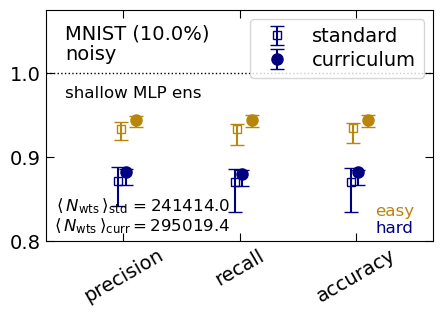

In [11]:
cols = {'easy':'darkgoldenrod','hard':'navy'}
labels = {'std':'standard','curr':'curriculum'}

plt.figure(figsize=(5,3))
ticks = {'precision':[0.2,'precision'],
         'recall':[0.5,'recall'],
         'accuracy':[0.8,'accuracy']}

plt.xlim(0,1)
ymin,ymax = 0.8,1.075
plt.ylim(ymin,ymax)
plt.xticks([ticks[key][0] for key in ticks.keys()],
           [ticks[key][1] for key in ticks.keys()],rotation=30)

rng_shift = np.random.RandomState(1992)
shift = 0.03*rng_shift.randn(4)
for key in ticks.keys():
    cc = 0
    for diff in ['easy','hard']:
        for learn in ['std','curr']:
            asc = ascs[diff][learn]
            Label = labels[learn] if (key=='precision') & (diff == 'hard') else None
            plt.errorbar([ticks[key][0] + shift[cc]],
                         [asc[key]['median']],
                         yerr=[[asc[key]['median']-asc[key]['16pc']],[asc[key]['84pc']-asc[key]['median']]],
                         c=cols[diff],
                         marker='s' if learn=='std' else 'o',
                         markersize=6 if learn=='std' else 8,
                         markerfacecolor='none' if learn=='std' else cols[diff],
                         capsize=5,ls='none',label=Label)
            cc += 1
    
xtext1 = 0.05
ytext1 = 1.04
ytext2 = 1.015
ytext3,ytext4 = 0.83,0.81
ytext5 = 0.97
ytext6 = 0.835
xtext2 = 0.85
plt.text(xtext1,ytext1,'MNIST ({0:.1f}%)'.format(Downsample*100),fontsize=FS3)
plt.text(xtext1,ytext2,'baseline' if Baseline else 'noisy',fontsize=FS3)
plt.text(xtext2,ytext3,'easy',fontsize=FSS,color=cols['easy'])
plt.text(xtext2,ytext4,'hard',fontsize=FSS,color=cols['hard'])
plt.text(xtext1,ytext5,Plot_Str+' MLP ens',fontsize=FSS)
plt.text(xtext1-0.03,ytext6,
         '$\\,\\langle \\, N_{{\\rm wts}} \\, \\rangle_{{\\rm std}}\\, = {0:.1f}$'.format(Avg_Wts['std']),fontsize=FSS)
plt.text(xtext1-0.03,ytext6-0.023,
         '$\\langle \\, N_{{\\rm wts}} \\, \\rangle_{{\\rm curr}} = {0:.1f}$'.format(Avg_Wts['curr']),fontsize=FSS)

plt.legend(loc='upper right')
plt.axhline(1.0,c='k',ls=':',lw=1)
if Save_Fig:
    outfile = Plot_Stem + '/performance'
    outfile += '_baseline' if Baseline else '_noisy'
    outfile += '.pdf'
    print('Writing to file: '+outfile)
    plt.savefig(outfile,bbox_inches='tight')
else:
    plt.show()